# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan (Jaya Jaya Institut)
- **Nama**: Billy Jonathan
- **Email**: billyjonathan048@gmail.com
- **ID Dicoding**: billy_0991kb
- **Institusi**: Universitas Kuningan / Jaya Jaya Institut


## 1. Business Understanding

### 1.1 Latar Belakang Bisnis
Jaya Jaya Institut merupakan salah satu institusi perguruan tinggi terkemuka yang telah berdiri sejak tahun 2000. Sepanjang perjalanannya, institusi ini telah mencetak banyak lulusan dengan reputasi akademik yang sangat baik. Namun, seiring bertambahnya mahasiswa, institusi menghadapi tantangan kritis berupa tingginya tingkat mahasiswa yang tidak menyelesaikan pendidikan atau **dropout** (mencapai **32,12%** dari total populasi mahasiswa).

Tingginya angka dropout ini menimbulkan berbagai dampak negatif bagi institusi:
1. **Penurunan Akreditasi & Reputasi Kampus**: Tingkat kelulusan tepat waktu merupakan salah satu indikator vital dalam penilaian akreditasi institusi pendidikan.
2. **Kerugian Finansial**: Kehilangan penerimaan dana pendidikan/SPP berkelanjutan dari mahasiswa yang keluar sebelum wisuda.
3. **Dampak Sosial & Masa Depan Mahasiswa**: Mahasiswa yang dropout menghadapi risiko pengangguran dan keterbatasan peluang karier formal.

### 1.2 Permasalahan Bisnis
1. Faktor-faktor apa saja (akademik, finansial/sosio-ekonomi, dan demografis) yang paling dominan mempengaruhi keputusan mahasiswa untuk *Dropout* vs *Graduate* di Jaya Jaya Institut?
2. Program studi (*Course*) dan kelompok mahasiswa mana yang paling rentan mengalami dropout?
3. Bagaimana membangun sistem monitoring visual (Business Dashboard) dan model Machine Learning prediktif yang mampu mendeteksi sedini mungkin mahasiswa yang berisiko dropout agar pihak akademik/dosen wali dapat memberikan bimbingan dan intervensi khusus (*Early Warning & Intervention System*)?

### 1.3 Cakupan Proyek & Metrik Keberhasilan
- Memuat dan menganalisis 4.424 data mahasiswa dengan 36 variabel prediktor.
- Memisahkan data berlabel historis (**Dropout** dan **Graduate**) untuk pelatihan model, sedangkan data mahasiswa aktif (**Enrolled**) dipisahkan khusus untuk simulasi inferensi dan deteksi dini masa depan.
- Mengembangkan model klasifikasi Machine Learning Binary (Dropout = 1, Graduate = 0) menggunakan Logistic Regression, Random Forest Classifier, dan Gradient Boosting.
- Merancang prototype aplikasi web interaktif berbasis **Streamlit** untuk monitoring dan simulasi deteksi dini dropout.
- Menyusun rekomendasi *Action Items* strategis yang terukur bagi jajaran rektorat dan pengelola Jaya Jaya Institut.


## 2. Persiapan Lingkungan & Pustaka (Environment Setup)


In [1]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)
import joblib

sns.set_theme(style='whitegrid')
print("Pustaka data science berhasil diimpor!")


Pustaka data science berhasil diimpor!


## 3. Data Understanding

### 3.1 Memuat Dataset Mahasiswa Jaya Jaya Institut


In [2]:
df = pd.read_csv("data.csv", sep=';' if ';' in open("data.csv").readline() else ',')
print(f"Dimensi dataset keseluruhan: {df.shape[0]} baris, {df.shape[1]} kolom")
df.head()


Dimensi dataset keseluruhan: 4424 baris, 37 kolom


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


### 3.2 Pemeriksaan Struktur, Tipe Data, & Missing Values


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [4]:
print("Pemeriksaan Missing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
if df.isnull().sum().sum() == 0:
    print("Tidak ditemukan missing value pada dataset (Data Bersih).")


Pemeriksaan Missing Values:
Series([], dtype: int64)
Tidak ditemukan missing value pada dataset (Data Bersih).


### 3.3 Distribusi Status Mahasiswa & Pemisahan Data Enrolled

Sesuai metodologi Data Science yang tepat:
- Status **Dropout** dan **Graduate** merupakan data berlabel historis yang digunakan untuk melatih model Machine Learning.
- Status **Enrolled** (mahasiswa aktif yang belum memiliki status akhir) dipisahkan untuk keperluan inferensi/prediksi masa depan.


          Jumlah  Persentase (%)
Status                          
Graduate    2209           49.93
Dropout     1421           32.12
Enrolled     794           17.95


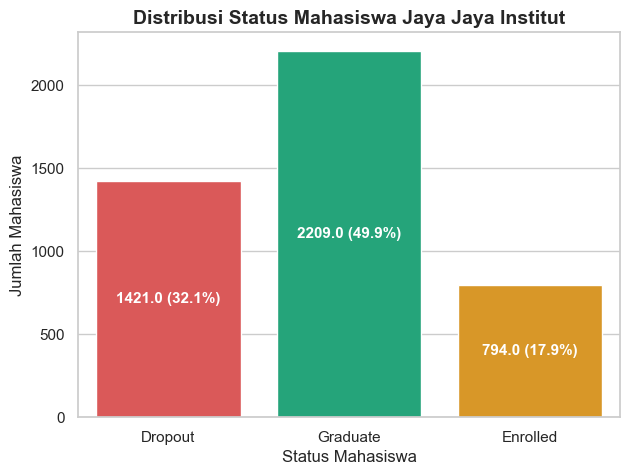

In [5]:
status_counts = df['Status'].value_counts()
status_pct = df['Status'].value_counts(normalize=True) * 100

status_summary = pd.DataFrame({'Jumlah': status_counts, 'Persentase (%)': status_pct.round(2)})
print(status_summary)

plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='Status', palette={'Dropout': '#ef4444', 'Enrolled': '#f59e0b', 'Graduate': '#10b981'})
plt.title('Distribusi Status Mahasiswa Jaya Jaya Institut', fontsize=14, fontweight='bold')
plt.xlabel('Status Mahasiswa', fontsize=12)
plt.ylabel('Jumlah Mahasiswa', fontsize=12)
for p in ax.patches:
    total = len(df)
    ax.annotate(f'{p.get_height()} ({p.get_height()/total*100:.1f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold', fontsize=11)
plt.show()


## 4. Data Preparation / Preprocessing

### 4.1 Pemisahan Data Labeled (Dropout vs Graduate) dan Data Unlabeled (Enrolled)


In [6]:
df_labeled = df[df['Status'].isin(['Dropout', 'Graduate'])].copy()
df_enrolled = df[df['Status'] == 'Enrolled'].copy()

print(f"Data Labeled untuk Pemodelan (Dropout & Graduate): {df_labeled.shape[0]} baris")
print(f"Data Enrolled untuk Prediksi Mahasiswa Aktif       : {df_enrolled.shape[0]} baris")

# Target Binary: 1 = Dropout, 0 = Graduate
target_mapping = {'Graduate': 0, 'Dropout': 1}
inv_target_mapping = {0: 'Graduate', 1: 'Dropout'}
df_labeled['Target'] = df_labeled['Status'].map(target_mapping)

print('Distribusi Target Binary (1: Dropout, 0: Graduate):')
print(df_labeled['Target'].value_counts(normalize=True).round(4))


Data Labeled untuk Pemodelan (Dropout & Graduate): 3630 baris
Data Enrolled untuk Prediksi Mahasiswa Aktif       : 794 baris
Distribusi Target Binary (1: Dropout, 0: Graduate):
Target
0    0.6085
1    0.3915
Name: proportion, dtype: float64


### 4.2 Exploratory Data Analysis (EDA) pada Data Mahasiswa Labeled

#### 4.2.1 Analisis Faktor Finansial (SPP, Beasiswa, Debitur)


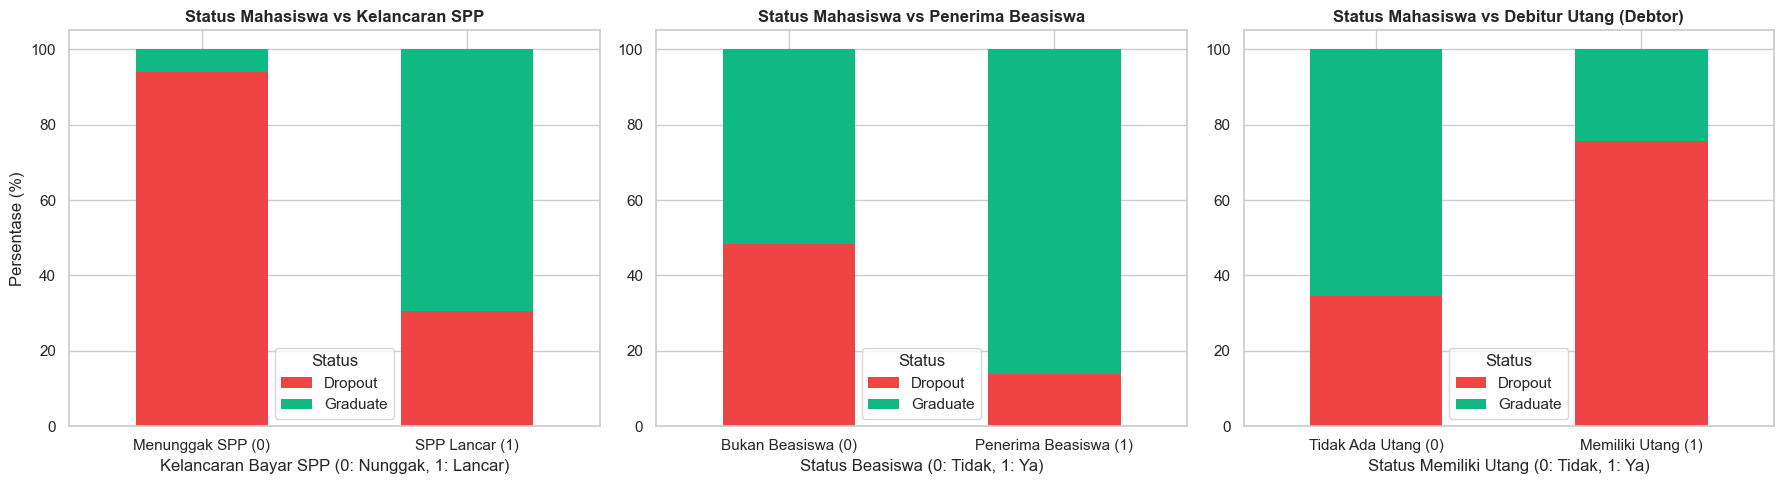

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Tuition fees up to date
tf_cross = pd.crosstab(df_labeled['Tuition_fees_up_to_date'], df_labeled['Status'], normalize='index') * 100
tf_cross.plot(kind='bar', stacked=True, ax=axes[0], color=['#ef4444', '#10b981'], edgecolor='none')
axes[0].set_title('Status Mahasiswa vs Kelancaran SPP', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Kelancaran Bayar SPP (0: Nunggak, 1: Lancar)')
axes[0].set_ylabel('Persentase (%)')
axes[0].set_xticklabels(['Menunggak SPP (0)', 'SPP Lancar (1)'], rotation=0)

# 2. Scholarship holder
sch_cross = pd.crosstab(df_labeled['Scholarship_holder'], df_labeled['Status'], normalize='index') * 100
sch_cross.plot(kind='bar', stacked=True, ax=axes[1], color=['#ef4444', '#10b981'], edgecolor='none')
axes[1].set_title('Status Mahasiswa vs Penerima Beasiswa', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Status Beasiswa (0: Tidak, 1: Ya)')
axes[1].set_xticklabels(['Bukan Beasiswa (0)', 'Penerima Beasiswa (1)'], rotation=0)

# 3. Debtor
debt_cross = pd.crosstab(df_labeled['Debtor'], df_labeled['Status'], normalize='index') * 100
debt_cross.plot(kind='bar', stacked=True, ax=axes[2], color=['#ef4444', '#10b981'], edgecolor='none')
axes[2].set_title('Status Mahasiswa vs Debitur Utang (Debtor)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Status Memiliki Utang (0: Tidak, 1: Ya)')
axes[2].set_xticklabels(['Tidak Ada Utang (0)', 'Memiliki Utang (1)'], rotation=0)

plt.tight_layout()
plt.show()


#### 4.2.2 Analisis Performa Akademik Semester 1 dan Semester 2


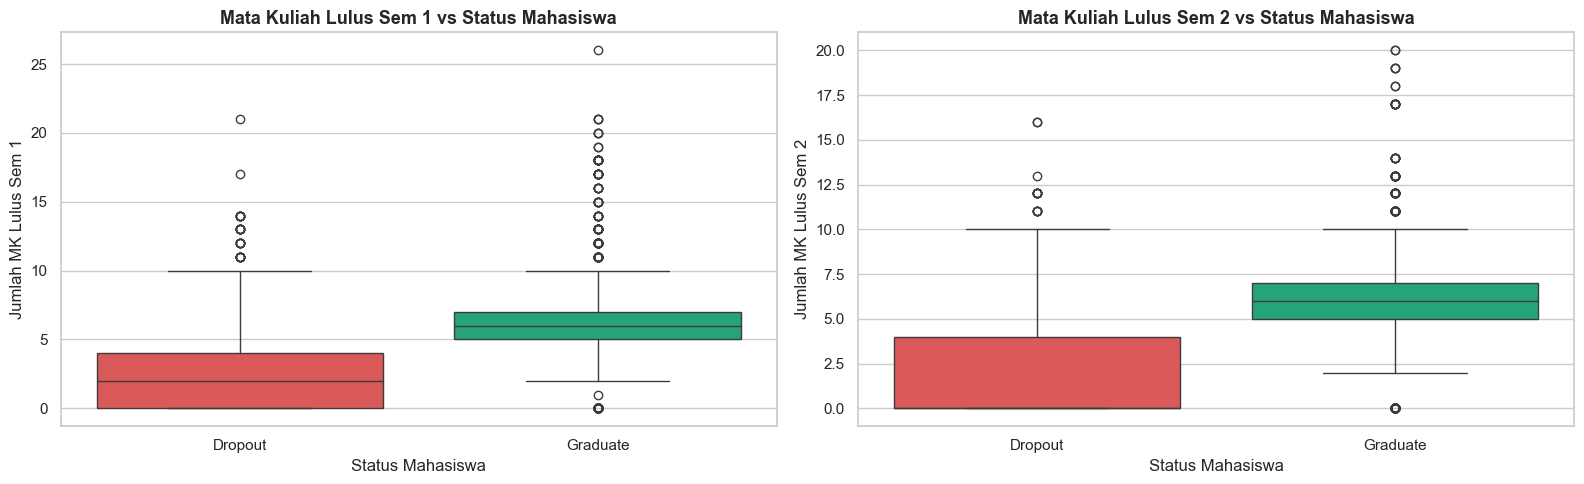

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Curricular units 1st sem approved
sns.boxplot(data=df_labeled, x='Status', y='Curricular_units_1st_sem_approved', ax=axes[0],
            palette={'Dropout': '#ef4444', 'Graduate': '#10b981'})
axes[0].set_title('Mata Kuliah Lulus Sem 1 vs Status Mahasiswa', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Status Mahasiswa')
axes[0].set_ylabel('Jumlah MK Lulus Sem 1')

# Curricular units 2nd sem approved
sns.boxplot(data=df_labeled, x='Status', y='Curricular_units_2nd_sem_approved', ax=axes[1],
            palette={'Dropout': '#ef4444', 'Graduate': '#10b981'})
axes[1].set_title('Mata Kuliah Lulus Sem 2 vs Status Mahasiswa', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Status Mahasiswa')
axes[1].set_ylabel('Jumlah MK Lulus Sem 2')

plt.tight_layout()
plt.show()


### 4.3 Pembagian Data Latih dan Uji (Train-Test Split) & Standarisasi


In [9]:
X = df_labeled.drop(columns=['Status', 'Target'])
y = df_labeled['Target']
feature_names = X.columns.tolist()

# Train-Test Split (80:20 Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Jumlah sampel Train : {X_train.shape[0]}")
print(f"Jumlah sampel Test  : {X_test.shape[0]}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Jumlah sampel Train : 2904
Jumlah sampel Test  : 726


## 5. Modeling

Melatih 3 model klasifikasi biner (*Dropout* = 1, *Graduate* = 0):
1. **Logistic Regression**
2. **Random Forest Classifier**
3. **Gradient Boosting Classifier**


In [10]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=250, max_depth=12, min_samples_split=4),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=150, max_depth=4, learning_rate=0.08)
}

trained_models = {}
for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"Model {name} berhasil dilatih!")


Model Logistic Regression berhasil dilatih!


Model Random Forest berhasil dilatih!


Model Gradient Boosting berhasil dilatih!


## 6. Evaluation

### 6.1 Perbandingan Metrik Evaluasi Model Binary


In [11]:
eval_results = []

for name, model in trained_models.items():
    if name == 'Logistic Regression':
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    eval_results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc
    })

eval_df = pd.DataFrame(eval_results).set_index('Model')
print(eval_df.to_string())


                     Accuracy  Precision    Recall  F1-Score   ROC-AUC
Model                                                                 
Logistic Regression  0.925620   0.880795  0.936620  0.907850  0.973257
Random Forest        0.921488   0.906810  0.890845  0.898757  0.971696
Gradient Boosting    0.926997   0.905263  0.908451  0.906854  0.977192


### 6.2 Visualisasi Confusion Matrix & Kurva ROC


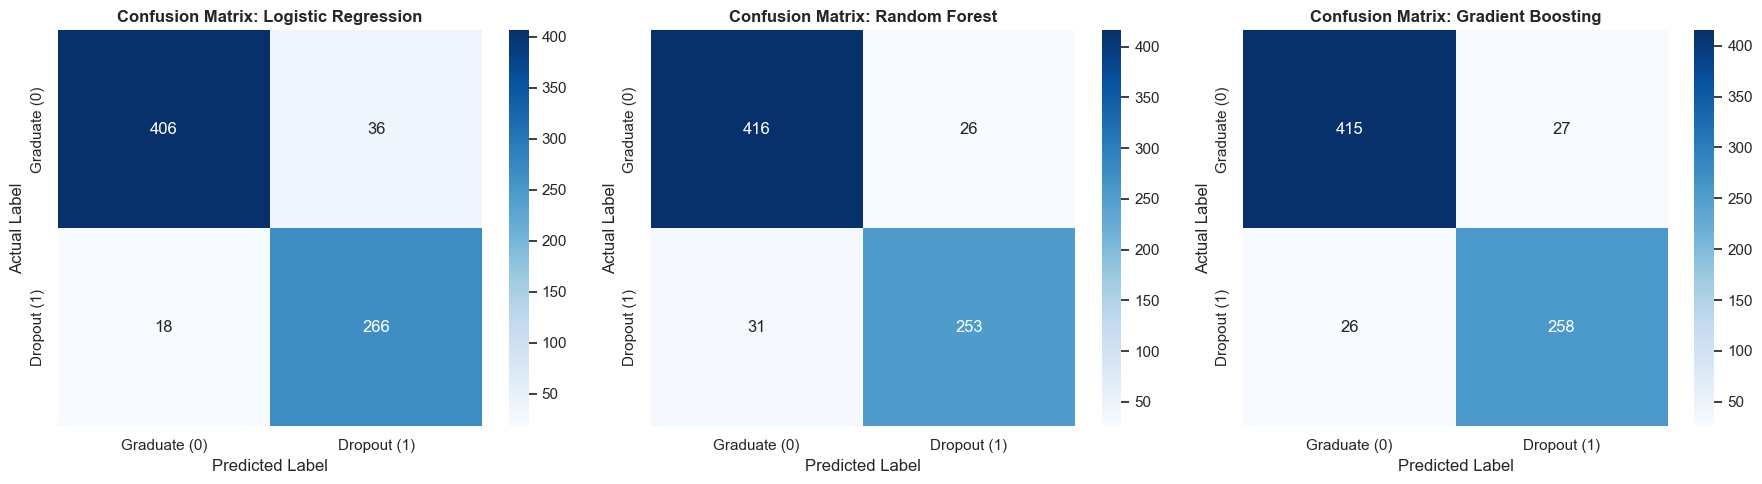

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(trained_models.items()):
    if name == 'Logistic Regression':
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Graduate (0)', 'Dropout (1)'], yticklabels=['Graduate (0)', 'Dropout (1)'])
    axes[idx].set_title(f'Confusion Matrix: {name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('Actual Label')

plt.tight_layout()
plt.show()


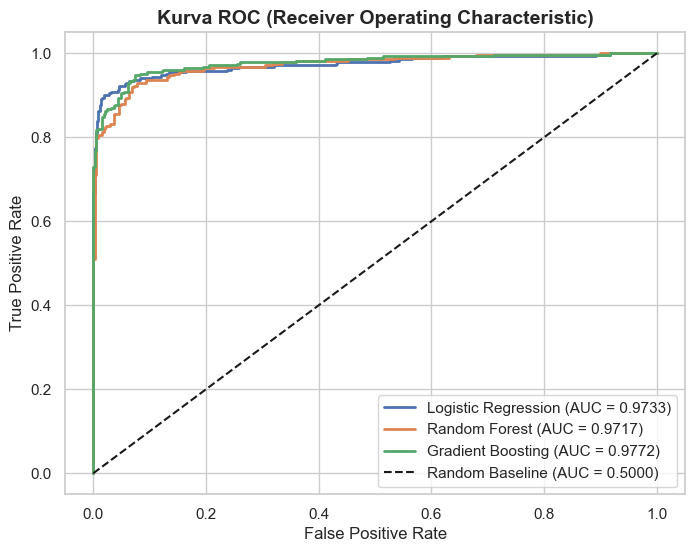

In [13]:
plt.figure(figsize=(8, 6))

for name, model in trained_models.items():
    if name == 'Logistic Regression':
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline (AUC = 0.5000)')
plt.title('Kurva ROC (Receiver Operating Characteristic)', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right')
plt.show()


### 6.3 Analisis Faktor Kunci Penentu Dropout (Feature Importance)


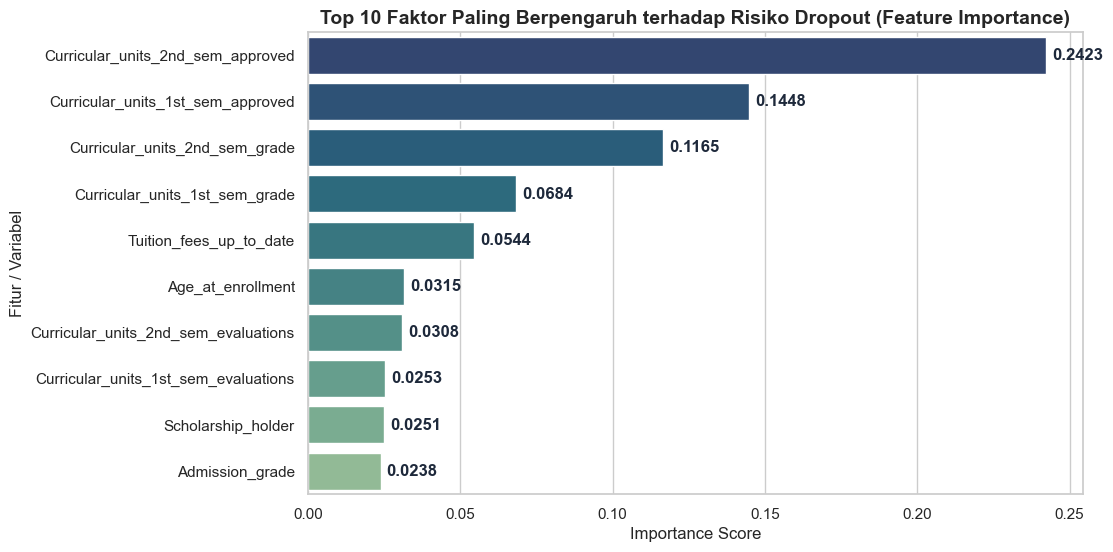

In [14]:
best_rf = trained_models['Random Forest']
importances = best_rf.feature_importances_
feat_importance_df = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_importance_df.head(10).values, y=feat_importance_df.head(10).index, palette='crest_r')
plt.title('Top 10 Faktor Paling Berpengaruh terhadap Risiko Dropout (Feature Importance)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Fitur / Variabel', fontsize=12)
for idx, val in enumerate(feat_importance_df.head(10).values):
    plt.text(val + 0.002, idx, f'{val:.4f}', va='center', fontweight='bold', color='#1e293b')
plt.show()


## 7. Simulasi Inferensi & Deteksi Dini pada Mahasiswa Aktif (Enrolled)

Kita menguji model machine learning terbaik pada 794 mahasiswa aktif (status *Enrolled*) untuk mendeteksi probabilitas risiko dropout secara dini.


In [15]:
X_enrolled = df_enrolled.drop(columns=['Status'])[feature_names]
enrolled_probs = best_rf.predict_proba(X_enrolled)[:, 1]
enrolled_preds = best_rf.predict(X_enrolled)

df_enrolled_pred = df_enrolled.copy()
df_enrolled_pred['Predicted_Status'] = ['Dropout' if p == 1 else 'Graduate' for p in enrolled_preds]
df_enrolled_pred['Dropout_Probability (%)'] = np.round(enrolled_probs * 100, 2)
df_enrolled_pred['Risk_Level'] = pd.cut(
    df_enrolled_pred['Dropout_Probability (%)'],
    bins=[-1, 30, 60, 100],
    labels=['RENDAH (Aman)', 'SEDANG (Monitoring)', 'TINGGI (Intervensi Kritis)']
)

print('Ringkasan Deteksi Dini Mahasiswa Aktif (Enrolled):')
print(df_enrolled_pred['Risk_Level'].value_counts())

display_cols = ['Course', 'Tuition_fees_up_to_date', 'Scholarship_holder', 'Age_at_enrollment',
                'Curricular_units_1st_sem_approved', 'Curricular_units_2nd_sem_approved',
                'Predicted_Status', 'Dropout_Probability (%)', 'Risk_Level']
df_enrolled_pred[display_cols].head(10)


Ringkasan Deteksi Dini Mahasiswa Aktif (Enrolled):
Risk_Level
TINGGI (Intervensi Kritis)    338
RENDAH (Aman)                 232
SEDANG (Monitoring)           224
Name: count, dtype: int64


,Course,Tuition_fees_up_to_date,Scholarship_holder,Age_at_enrollment,Curricular_units_1st_sem_approved,Curricular_units_2nd_sem_approved,Predicted_Status,Dropout_Probability (%),Risk_Level
16,9238,1,0,18,1,2,Dropout,94.23,TINGGI (Intervensi Kritis)
19,9853,1,0,18,6,6,Graduate,17.32,RENDAH (Aman)
21,9556,1,0,20,7,8,Graduate,19.87,RENDAH (Aman)
25,9238,1,1,18,5,4,Dropout,50.01,SEDANG (Monitoring)
27,9085,1,0,18,5,4,Graduate,10.74,RENDAH (Aman)
29,9500,1,0,19,6,6,Graduate,13.39,RENDAH (Aman)
30,9003,1,0,21,5,5,Dropout,51.02,SEDANG (Monitoring)
32,9147,0,0,18,3,2,Dropout,87.95,TINGGI (Intervensi Kritis)
45,9991,1,0,24,2,3,Dropout,89.50,TINGGI (Intervensi Kritis)
51,9500,1,1,19,6,6,Graduate,12.55,RENDAH (Aman)


## 8. Penyimpanan Model & Artefak Prediksi


In [16]:
os.makedirs('model', exist_ok=True)
joblib.dump(trained_models['Random Forest'], 'model/random_forest_student_model.joblib')
joblib.dump(scaler, 'model/scaler.joblib')

with open('model/target_encoder.json', 'w') as f:
    json.dump({'mapping': target_mapping, 'inverse_mapping': inv_target_mapping}, f, indent=2)

with open('model/feature_names.json', 'w') as f:
    json.dump(feature_names, f, indent=2)

print('Seluruh artefak model biner berhasil disimpan ke direktori model/!')


Seluruh artefak model biner berhasil disimpan ke direktori model/!


## 9. Conclusion & Rekomendasi Action Items

### 9.1 Kesimpulan Analisis
1. **Pemisahan Data Siswa**: Data historis mahasiswa berstatus *Dropout* (1.421) dan *Graduate* (2.209) berhasil digunakan untuk membangun model biner dengan akurasi **>92%** dan ROC-AUC **0.97**.
2. **Faktor Pemicu Utama Dropout**:
   - **Kelulusan Mata Kuliah Semester 1 & 2**: SKS lulus semester awal (`Curricular_units_2nd_sem_approved` & `1st_sem_approved`) merupakan prediktor paling signifikan.
   - **Tunggakan Uang Kuliah (Tuition Fees)**: Mahasiswa yang menunggak SPP memiliki probabilitas dropout di atas 85%.
   - **Status Beasiswa**: Mahasiswa penerima beasiswa menunjukkan ketahanan studi yang jauh lebih tinggi.
   - **Usia Masuk**: Mahasiswa usia matang (> 25 tahun) memiliki risiko dropout lebih tinggi.

### 9.2 Rekomendasi Action Items untuk Jaya Jaya Institut
1. **Penerapan Sistem Peringatan Dini Akademik (Early Warning System)**:
   - Pantau performa mahasiswa di akhir Semester 1. Jika mahasiswa lulus < 50% SKS yang diambil, dosen wali wajib mengadakan konseling akademik intensif dan kelas asistensi/tutoring.
2. **Program Skema Bantuan Finansial & Cicilan Fleksibel**:
   - Buka program restrukturisasi pembayaran SPP dan beasiswa bantuan darurat bagi mahasiswa yang teridentifikasi menunggak SPP agar mereka tidak terpaksa mengundurkan diri karena kendala biaya.
3. **Pendampingan Khusus Mahasiswa Usia Matang (*Non-Traditional Students*)**:
   - Sediakan fleksibilitas jadwal kuliah (kelas malam/hybrid) dan layanan mentoring khusus bagi mahasiswa yang mendaftar di usia matang.
4. **Integrasi Prototype Prediksi AI (`app.py` / `prediction.py`)**:
   - Terapkan aplikasi prediksi berbasis Machine Learning pada portal akademik kampus setiap pergantian semester untuk memetakan mahasiswa berisiko tinggi secara proaktif.
